# Steam Dataset EDA (Parquet)

This notebook loads the ingested Parquet file (just a a sample of the first 500 games) and saves charts to `reports/eda` as PNG files.

In [ ]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

parquet_path = "../data/processed/steam_v1.parquet"
output_dir = "../reports/eda"
top_n = 15

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(parquet_path):
    raise FileNotFoundError(f"Parquet file not found at: {parquet_path}")

df = pd.read_parquet(parquet_path)
sns.set_theme(style="whitegrid")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 480,025
Columns: 8


,recommendationid,voted_up,author_steamid,author_playtime_forever,AppID,name,genres,tags
0,147937429.0,1,76561199550893216,59161,10,Counter-Strike,['Action'],"{'Action': 5472, 'FPS': 4897, 'Multiplayer': 3..."
1,166664841.0,1,76561199161536896,436,10,Counter-Strike,['Action'],"{'Action': 5472, 'FPS': 4897, 'Multiplayer': 3..."
2,166664763.0,1,76561198046827632,23750,10,Counter-Strike,['Action'],"{'Action': 5472, 'FPS': 4897, 'Multiplayer': 3..."
3,166663001.0,0,76561199374468448,361,10,Counter-Strike,['Action'],"{'Action': 5472, 'FPS': 4897, 'Multiplayer': 3..."
4,166658743.0,1,76561198018922960,1497,10,Counter-Strike,['Action'],"{'Action': 5472, 'FPS': 4897, 'Multiplayer': 3..."


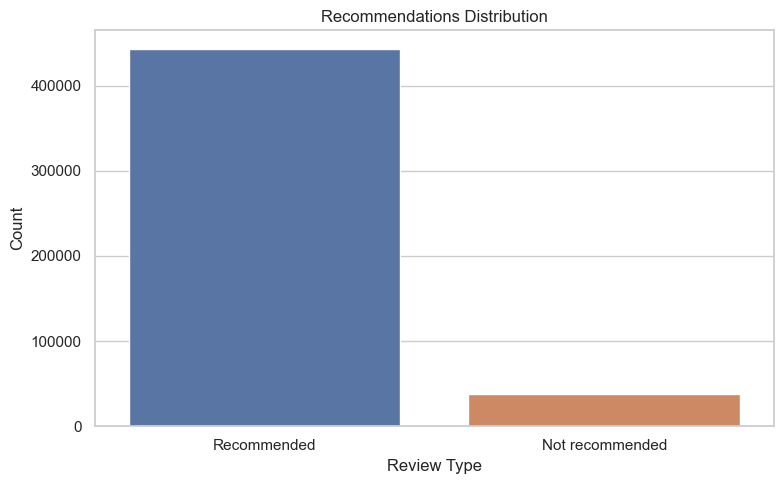

Raw voted_up examples:
voted_up
1    442652
0     37373
Name: count, dtype: int64


In [10]:
# 1) Recommendation distribution
plt.figure(figsize=(8, 5))

# Normalize voted_up values so bool, numeric, and string formats are handled consistently
true_tokens = {"true", "t", "1", "yes", "y", "recommended"}
false_tokens = {"false", "f", "0", "no", "n", "not recommended"}

raw_vote = df["voted_up"].astype(str).str.strip().str.lower()
voted_up_norm = raw_vote.map(
    lambda x: "Recommended" if x in true_tokens else (
        "Not recommended" if x in false_tokens else "Unknown"
    )
)

voted_counts = voted_up_norm.value_counts()
order = [label for label in ["Recommended", "Not recommended", "Unknown"] if label in voted_counts.index]

sns.barplot(x=order, y=voted_counts.reindex(order).values, hue=order, legend=False)
plt.title("Recommendations Distribution")
plt.xlabel("Review Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "01_recommendations_distribution.png"), dpi=200)
plt.show()
plt.close()

print("Raw voted_up examples:")
print(raw_vote.value_counts(dropna=False).head(10))

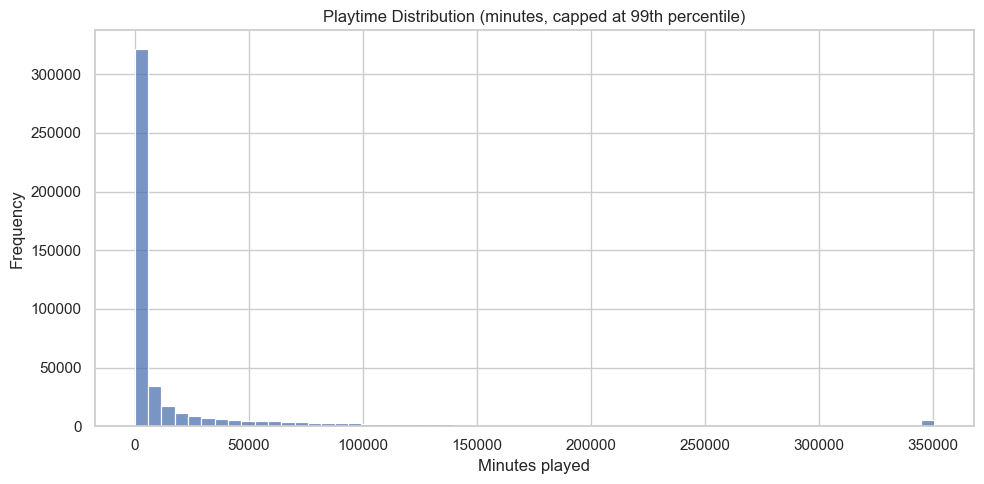

In [5]:
# 2) Playtime distribution (capped at percentile 99 for readability)
playtime = pd.to_numeric(df["author_playtime_forever"], errors="coerce").dropna()
playtime_capped = playtime.clip(upper=playtime.quantile(0.99))

plt.figure(figsize=(10, 5))
sns.histplot(playtime_capped, bins=60)
plt.title("Playtime Distribution (minutes, capped at 99th percentile)")
plt.xlabel("Minutes played")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "02_playtime_distribution.png"), dpi=200)
plt.show()
plt.close()

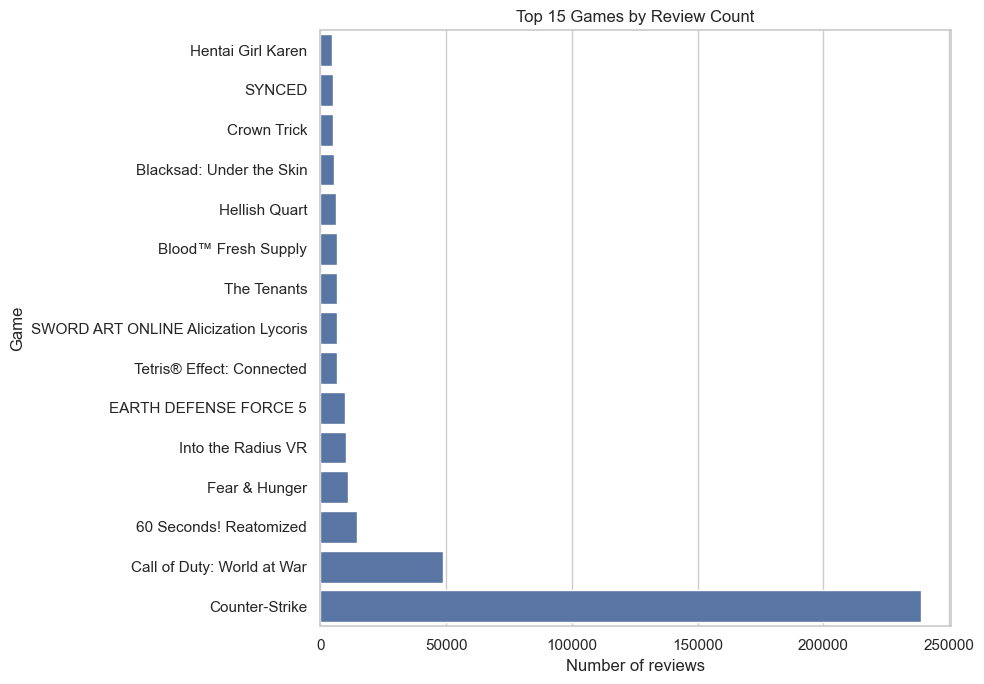

In [6]:
# 3) Top games by number of reviews
top_games = (
    df.groupby("name", dropna=True)
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_games.values, y=top_games.index, orient="h")
plt.title(f"Top {top_n} Games by Review Count")
plt.xlabel("Number of reviews")
plt.ylabel("Game")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "03_top_games_by_reviews.png"), dpi=200)
plt.show()
plt.close()

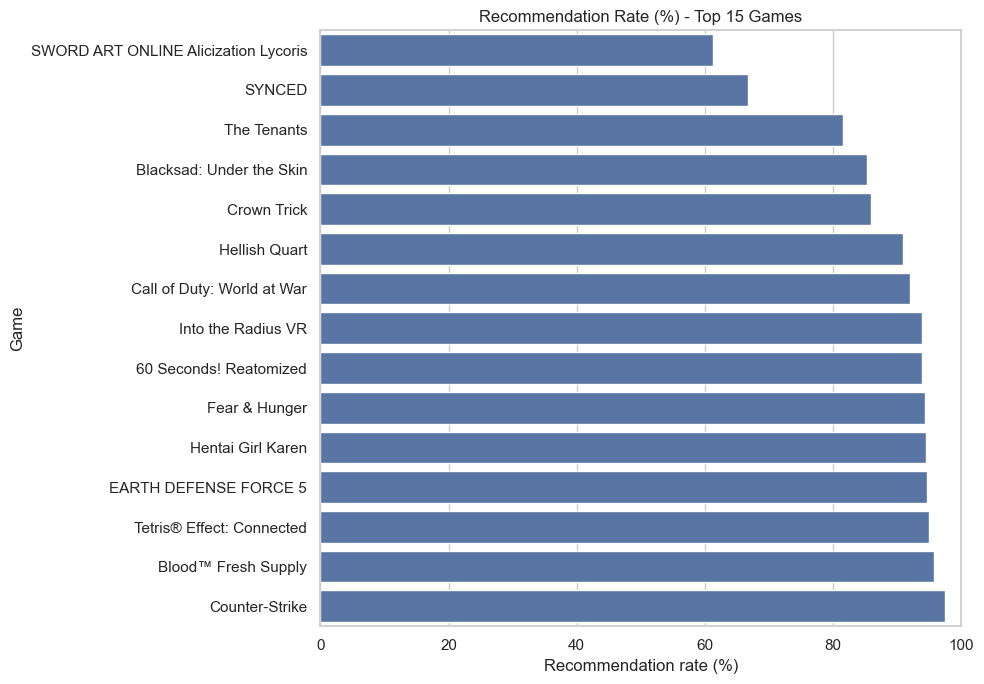

In [7]:
# 4) Recommendation rate for top games
top_game_names = (
    df.groupby("name", dropna=True)
    .size()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

rec_rate = (
    df[df["name"].isin(top_game_names)]
    .groupby("name", dropna=True)["voted_up"]
    .mean()
    .sort_values(ascending=True)
    * 100
)

plt.figure(figsize=(10, 7))
sns.barplot(x=rec_rate.values, y=rec_rate.index, orient="h")
plt.title(f"Recommendation Rate (%) - Top {top_n} Games")
plt.xlabel("Recommendation rate (%)")
plt.ylabel("Game")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "04_recommendation_rate_top_games.png"), dpi=200)
plt.show()
plt.close()

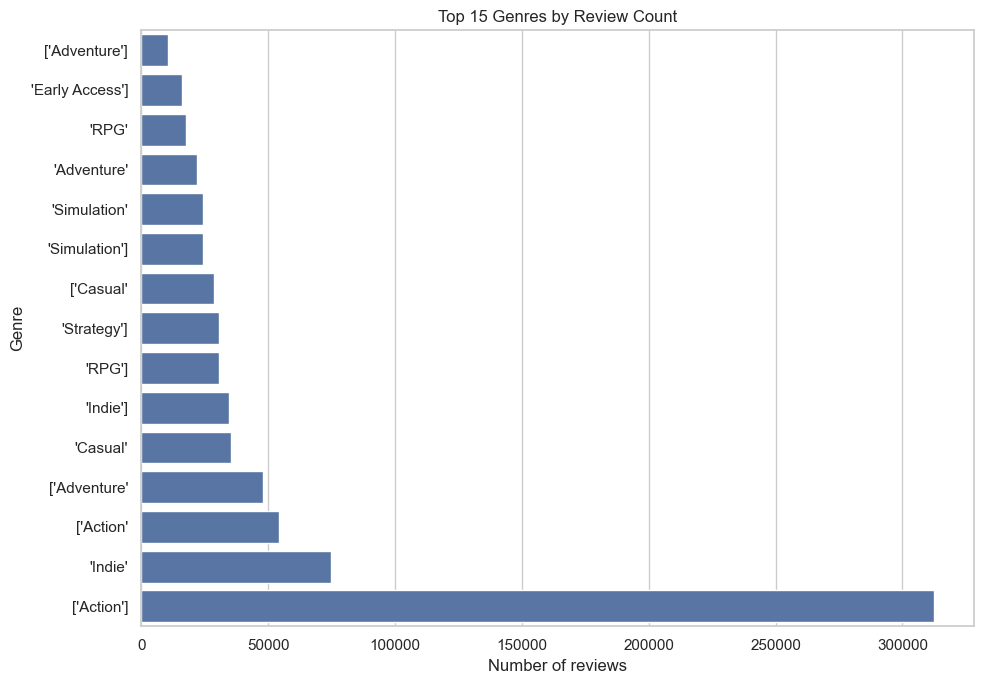

EDA complete. PNG files saved in: reports/eda


In [8]:
# 5) Top genres by number of reviews
genres = (
    df["genres"]
    .fillna("")
    .astype(str)
    .str.split(",")
    .explode()
    .str.strip()
)
genres = genres[genres != ""]
top_genres = genres.value_counts().head(top_n).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_genres.values, y=top_genres.index, orient="h")
plt.title(f"Top {top_n} Genres by Review Count")
plt.xlabel("Number of reviews")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "05_top_genres.png"), dpi=200)
plt.show()
plt.close()

print(f"EDA complete. PNG files saved in: {output_dir}")